In [1]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_rows', None)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

con = duckdb.connect()

con.execute("""
    CREATE OR REPLACE VIEW loans AS
    SELECT * FROM read_csv_auto('accepted_cleaned_v1.csv')
""")

con.execute("""
    CREATE OR REPLACE VIEW loans_pd AS
    SELECT *,
        CASE
            WHEN loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off') THEN 1
            WHEN loan_status IN ('Fully Paid', 'Does not meet the credit policy. Status:Fully Paid') THEN 0
        END AS target
    FROM loans
    WHERE loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off',
                           'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid')
""")

loan_info = con.sql("""
    SELECT id, funded_amnt, int_rate, TRIM(term) AS term, grade, issue_year
    FROM loans_pd
    WHERE issue_year = 2015
""").df()

pd_pred = pd.read_csv('test_2015_pd_predictions.csv')

profit_df = loan_info.merge(pd_pred, on='id', how='inner')
print(profit_df.shape)
profit_df.head()

(375145, 8)


,id,funded_amnt,int_rate,term,grade,issue_year,target,pd_pred
0,65702598,8000.0,9.99,36 months,B,2015,0,0.111110
1,65726647,10000.0,11.49,36 months,B,2015,0,0.122268
2,65716612,10000.0,14.33,36 months,C,2015,0,0.247284
3,65776809,5100.0,16.99,36 months,D,2015,0,0.242764
4,65606819,20000.0,9.99,36 months,B,2015,1,0.084037


In [2]:
realization_pct = {
    ('36 months','A'): 0.8374, ('36 months','B'): 0.8209, ('36 months','C'): 0.7976,
    ('36 months','D'): 0.7790, ('36 months','E'): 0.7611, ('36 months','F'): 0.7543, ('36 months','G'): 0.7193,
    ('60 months','A'): 0.7684, ('60 months','B'): 0.7619, ('60 months','C'): 0.7351,
    ('60 months','D'): 0.7004, ('60 months','E'): 0.6837, ('60 months','F'): 0.6629, ('60 months','G'): 0.6434,
}

profit_df['term_months'] = profit_df['term'].str.extract(r'(\d+)').astype(int)
profit_df['mr'] = profit_df['int_rate'] / 100.0 / 12.0

# 1) 월상환액
profit_df['monthly_payment'] = (profit_df['funded_amnt'] * profit_df['mr'] * (1 + profit_df['mr'])**profit_df['term_months']
                                 / ((1 + profit_df['mr'])**profit_df['term_months'] - 1))

# 2) 상각기준 기대이자
profit_df['expected_interest_amortized'] = profit_df['monthly_payment'] * profit_df['term_months'] - profit_df['funded_amnt']

# 3) 이자수익(조건부) = 상각기준 기대이자 × 실현률
profit_df['realization'] = profit_df.apply(lambda row: realization_pct[(row['term'], row['grade'])], axis=1)
profit_df['interest_income_conditional'] = profit_df['expected_interest_amortized'] * profit_df['realization']

# 4) 예상손실(EL)
LGD = 0.898
profit_df['EL'] = profit_df['pd_pred'] * LGD * profit_df['funded_amnt']

# 5) 기대이익 = (1-PD) × 이자수익(조건부) − EL
profit_df['expected_profit'] = (1 - profit_df['pd_pred']) * profit_df['interest_income_conditional'] - profit_df['EL']

print(profit_df[['funded_amnt','grade','pd_pred','interest_income_conditional','EL','expected_profit']].head(10))
print()
print('전체 기대이익 합계:', profit_df['expected_profit'].sum())
print('건당 평균 기대이익:', profit_df['expected_profit'].mean())

   funded_amnt grade   pd_pred  interest_income_conditional           EL  \
0       8000.0     B  0.111110                  1060.272656   798.213543   
1      10000.0     B  0.122268                  1534.795893  1097.967340   
2      10000.0     C  0.247284                  1883.712307  2220.609275   
3       5100.0     D  0.242764                  1125.598182  1111.809908   
4      20000.0     B  0.084037                  2650.681640  1509.306238   
5       2800.0     B  0.257281                   410.109617   646.906257   
6      16000.0     B  0.118367                  1721.931639  1700.693617   
7      12000.0     C  0.310614                  3270.189755  3347.177071   
8       5000.0     B  0.074898                   662.670410   336.292474   
9      13950.0     D  0.173046                  2993.331121  2167.763399   

   expected_profit  
0       144.252321  
1       249.172009  
2      -802.708663  
3      -259.466281  
4       918.619816  
5      -342.309875  
6      -182.5814

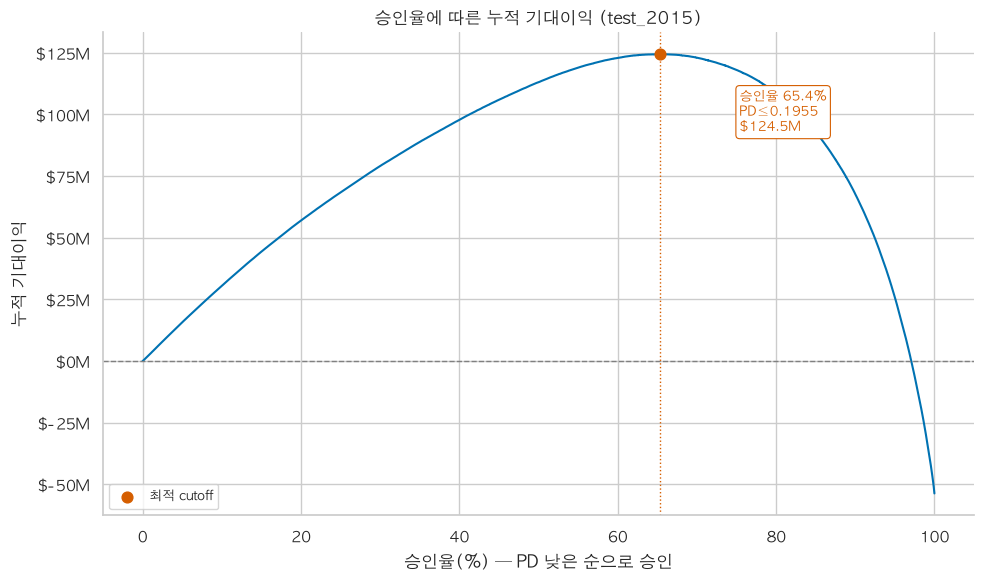

최적 cutoff 지점:
PD 기준값: 0.1955
승인율: 65.4 %
누적 기대이익: 124473346.68


In [ ]:
from matplotlib.ticker import FuncFormatter

sorted_df = profit_df.sort_values('pd_pred').reset_index(drop=True)
sorted_df['cum_approved'] = np.arange(1, len(sorted_df) + 1)
sorted_df['approval_rate'] = sorted_df['cum_approved'] / len(sorted_df) * 100
sorted_df['cum_expected_profit'] = sorted_df['expected_profit'].cumsum()

optimal_idx = sorted_df['cum_expected_profit'].idxmax()
optimal_row = sorted_df.loc[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=sorted_df, x='approval_rate', y='cum_expected_profit', color='#0072B2', ax=ax)
ax.set_xlabel('승인율(%) — PD 낮은 순으로 승인')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_ylabel('누적 기대이익')
ax.set_title('승인율에 따른 누적 기대이익 (test_2015)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.scatter(
    optimal_row['approval_rate'], optimal_row['cum_expected_profit'],
    color='#D55E00', s=60, zorder=5, label='최적 cutoff'
)
ax.axvline(optimal_row['approval_rate'], color='#D55E00', linestyle=':', linewidth=1)
ax.annotate(
    f"승인율 {optimal_row['approval_rate']:.1f}%\nPD≤{optimal_row['pd_pred']:.4f}\n${optimal_row['cum_expected_profit']/1e6:.1f}M",
    xy=(optimal_row['approval_rate'], optimal_row['cum_expected_profit']),
    xytext=(optimal_row['approval_rate']+10, optimal_row['cum_expected_profit']*0.75),
    fontsize=9, color='#D55E00',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#D55E00', linewidth=0.8)
)
ax.legend(loc='lower left', fontsize=9)

sns.despine()
plt.tight_layout()
# plt.savefig('images/6-3_cutoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('최적 cutoff 지점:')
print('PD 기준값:', round(optimal_row['pd_pred'], 4))
print('승인율:', round(optimal_row['approval_rate'], 2), '%')
print('누적 기대이익:', round(optimal_row['cum_expected_profit'], 2))

In [7]:
cutoff_pd = optimal_row['pd_pred']

approved = profit_df[profit_df['pd_pred'] <= cutoff_pd]
rejected = profit_df[profit_df['pd_pred'] > cutoff_pd]

print('=== 전체 test_2015 ===')
print('건수:', len(profit_df), '| 실제 부도율:', round(profit_df['target'].mean() * 100, 2), '%')

print('=== 승인군(PD ≤', round(cutoff_pd, 4), ') ===')
print('건수:', len(approved), '| 실제 부도율:', round(approved['target'].mean() * 100, 2), '%')
print('실제 이자수익 합계(approved만, total_rec_int 필요 — 나중에 추가 가능)')

print('=== 거절군(PD >', round(cutoff_pd, 4), ') ===')
print('건수:', len(rejected), '| 실제 부도율:', round(rejected['target'].mean() * 100, 2), '%')

=== 전체 test_2015 ===
건수: 375145 | 실제 부도율: 20.18 %
=== 승인군(PD ≤ 0.1955 ) ===
건수: 245353 | 실제 부도율: 11.7 %
실제 이자수익 합계(approved만, total_rec_int 필요 — 나중에 추가 가능)
=== 거절군(PD > 0.1955 ) ===
건수: 129792 | 실제 부도율: 36.21 %


In [10]:
loan_info_2016 = con.sql("""
    SELECT id, funded_amnt, int_rate, TRIm(term) AS term, grade, issue_year
    FROM loans_pd
    WHERE issue_year = 2016
""").df()

pd_pred_2016 = pd.read_csv('test_2016_pd_predictions.csv')
profit_df_2016 = loan_info_2016.merge(pd_pred_2016, on='id', how='inner')

profit_df_2016['term_months'] = profit_df_2016['term'].str.extract(r'(\d+)').astype(int)
profit_df_2016['mr'] = profit_df_2016['int_rate'] / 100.0 / 12.0
profit_df_2016['monthly_payment'] = (profit_df_2016['funded_amnt'] * profit_df_2016['mr'] * (1 + profit_df_2016['mr'])**profit_df_2016['term_months']
                                      / ((1 + profit_df_2016['mr'])**profit_df_2016['term_months'] - 1))
profit_df_2016['expected_interest_amortized'] = profit_df_2016['monthly_payment'] * profit_df_2016['term_months'] - profit_df_2016['funded_amnt']
profit_df_2016['realization'] = profit_df_2016.apply(lambda row: realization_pct[(row['term'], row['grade'])], axis=1)
profit_df_2016['interest_income_conditional'] = profit_df_2016['expected_interest_amortized'] * profit_df_2016['realization']
profit_df_2016['EL'] = profit_df_2016['pd_pred'] * LGD * profit_df_2016['funded_amnt']
profit_df_2016['expected_profit'] = (1 - profit_df_2016['pd_pred']) * profit_df_2016['interest_income_conditional'] - profit_df_2016['EL']

# 중요: 2016에서 새 cutoff를 다시 찾는 게 아니라, 2015에서 정한 cutoff(0.1955)를 그대로 적용해서 검증
approved_2016 = profit_df_2016[profit_df_2016['pd_pred'] <= cutoff_pd]
rejected_2016 = profit_df_2016[profit_df_2016['pd_pred'] > cutoff_pd]

print('=== 전체 test_2016 ===')
print('건수:', len(profit_df_2016), '| 실제 부도율:', round(profit_df_2016['target'].mean() * 100, 2), '%')
print('=== 승인군(2015 기준 cutoff 적용) ===')
print('건수:', len(approved_2016), '| 실제 부도율:', round(approved_2016['target'].mean() * 100, 2), '%')
print('=== 거절군 ===')
print('건수:', len(rejected_2016), '| 실제 부도율:', round(rejected_2016['target'].mean() * 100, 2), '%')

=== 전체 test_2016 ===
건수: 287819 | 실제 부도율: 23.26 %
=== 승인군(2015 기준 cutoff 적용) ===
건수: 193620 | 실제 부도율: 15.23 %
=== 거절군 ===
건수: 94199 | 실제 부도율: 39.76 %


In [11]:
def find_optimal_cutoff(df, lgd_value):
    temp = df.copy()
    temp['EL'] = temp['pd_pred'] * lgd_value * temp['funded_amnt']
    temp['expected_profit'] = (1 - temp['pd_pred']) * temp['interest_income_conditional'] - temp['EL']
    temp = temp.sort_values('pd_pred').reset_index(drop=True)
    temp['cum_expected_profit'] = temp['expected_profit'].cumsum()
    temp['approval_rate'] = (np.arange(1, len(temp)+1) / len(temp)) * 100
    idx = temp['cum_expected_profit'].idxmax()
    return temp.loc[idx, ['pd_pred', 'approval_rate', 'cum_expected_profit']]

for lgd_test in [0.85, 0.898, 0.95]:
    result = find_optimal_cutoff(profit_df, lgd_test)
    print(f'LGD={lgd_test}: PD cutoff={result["pd_pred"]:.4f}, 승인율={result["approval_rate"]:.2f}%, 누적기대이익={result["cum_expected_profit"]:,.0f}')

LGD=0.85: PD cutoff=0.2121, 승인율=69.58%, 누적기대이익=142,053,813
LGD=0.898: PD cutoff=0.1955, 승인율=65.40%, 누적기대이익=124,473,347
LGD=0.95: PD cutoff=0.1793, 승인율=60.83%, 누적기대이익=107,777,678


In [12]:
pd_pred_logisticA = pd.read_csv('test_2015_pd_predictions_logisticA.csv')

profit_df_logisticA = loan_info.merge(pd_pred_logisticA, on='id', how='inner')
profit_df_logisticA['term_months'] = profit_df_logisticA['term'].str.extract(r'(\d+)').astype(int)
profit_df_logisticA['mr'] = profit_df_logisticA['int_rate'] / 100.0 / 12.0
profit_df_logisticA['monthly_payment'] = (profit_df_logisticA['funded_amnt'] * profit_df_logisticA['mr'] * (1 + profit_df_logisticA['mr'])**profit_df_logisticA['term_months']
                                           / ((1 + profit_df_logisticA['mr'])**profit_df_logisticA['term_months'] - 1))
profit_df_logisticA['expected_interest_amortized'] = profit_df_logisticA['monthly_payment'] * profit_df_logisticA['term_months'] - profit_df_logisticA['funded_amnt']
profit_df_logisticA['realization'] = profit_df_logisticA.apply(lambda row: realization_pct[(row['term'], row['grade'])], axis=1)
profit_df_logisticA['interest_income_conditional'] = profit_df_logisticA['expected_interest_amortized'] * profit_df_logisticA['realization']

result_logisticA = find_optimal_cutoff(profit_df_logisticA, 0.898)
result_treeA = find_optimal_cutoff(profit_df, 0.898)

print('=== 트리A 기준 ===')
print(result_treeA)
print()
print('=== 로지스틱A 기준 ===')
print(result_logisticA)

=== 트리A 기준 ===
pd_pred                1.954750e-01
approval_rate          6.540218e+01
cum_expected_profit    1.244733e+08
Name: 245352, dtype: float64

=== 로지스틱A 기준 ===
pd_pred                1.882834e-01
approval_rate          6.318997e+01
cum_expected_profit    1.130318e+08
Name: 237053, dtype: float64
